# Netflix Global Content Catalog — SQL-Driven EDA
### Executive Exploratory Data Analysis & Strategic Insights
**Author:** Data Strategy & Analytics  
**Database:** SQLite 3 (`data/processed/netflix.db`)  
**Scope:** 8,797 Normalized Titles  

---
## Project Overview
This notebook presents a rigorous, SQL-driven analysis of Netflix's content library. Rather than relying on pandas abstractions for data aggregation, all business calculations, joins, and frequency distributions are computed directly in SQLite using standard SQL queries and normalized 1NF junction tables (`genre_map` and `country_map`).

### Key Analytical Themes:
1. **Catalog Composition:** The dynamic balance between Movies and TV Shows.
2. **Genre Mix:** Dominant thematic categories across content formats.
3. **Audience Maturity:** Rating distributions and parental guidance profiles.
4. **The Strategic Pivot:** Historical production vintages vs platform acquisition velocity.
5. **Geographic Footprint:** Production hubs, catalog concentration, and regional specialization.
6. **Release Cadence:** Month-over-month addition velocity and calendar seasonality.


In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure cohesive dark-mode visualization theme
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.facecolor': '#141414',
    'axes.facecolor': '#1F1F1F',
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#B3B3B3',
    'ytick.color': '#B3B3B3',
    'grid.color': '#2A2A2A',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

NETFLIX_RED = '#E50914'
ACCENT_BLUE = '#3B82F6'
ACCENT_GOLD = '#F59E0B'

# Database connection
DB_PATH = os.path.join('..', 'data', 'processed', 'netflix.db')
if not os.path.exists(DB_PATH):
    DB_PATH = os.path.join('data', 'processed', 'netflix.db')

conn = sqlite3.connect(DB_PATH)
print(f'Connected to database: {DB_PATH}')


Connected to database: ..\data\processed\netflix.db


## 1. Database Architecture & Table Verification
Let us verify the normalized schema and record counts across the primary table and junction tables.


In [2]:
tables_query = """
SELECT 'netflix_titles (Master Catalog)' AS table_name, COUNT(*) AS record_count FROM netflix_titles
UNION ALL
SELECT 'genre_map (1NF Junction)', COUNT(*) FROM genre_map
UNION ALL
SELECT 'country_map (1NF Junction)', COUNT(*) FROM country_map;
"""
pd.read_sql_query(tables_query, conn)


,table_name,record_count
0,netflix_titles (Master Catalog),8797
1,genre_map (1NF Junction),19303
2,country_map (1NF Junction),10833


## 2. Content Distribution: Movies vs. TV Shows
**Business Question:** What is the macro split between Movies and TV Shows, and how do their durations compare?


,type,title_count,pct_of_catalog,avg_duration,min_duration,max_duration
0,Movie,6131,69.7,99.6,3,312
1,TV Show,2666,30.3,1.8,1,17


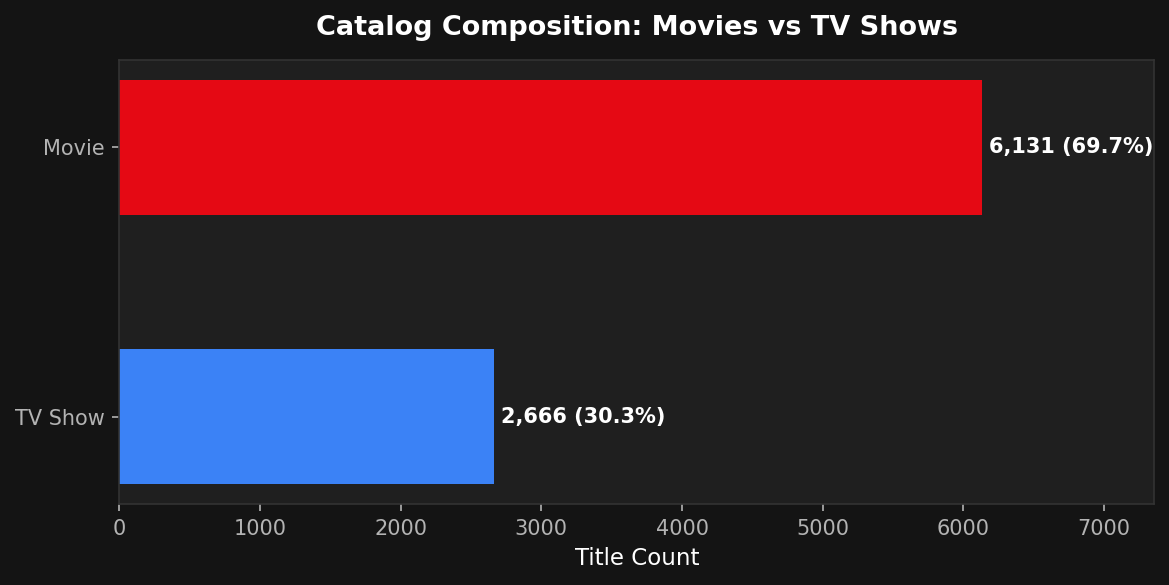

In [3]:
sql_dist = """
SELECT 
    type,
    COUNT(*) AS title_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM netflix_titles), 1) AS pct_of_catalog,
    ROUND(AVG(duration_value), 1) AS avg_duration,
    MIN(duration_value) AS min_duration,
    MAX(duration_value) AS max_duration
FROM netflix_titles
GROUP BY type
ORDER BY title_count DESC;
"""
df_dist = pd.read_sql_query(sql_dist, conn)
display(df_dist)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
bars = ax.barh(df_dist['type'], df_dist['title_count'], color=[NETFLIX_RED, ACCENT_BLUE], height=0.5)
ax.set_title('Catalog Composition: Movies vs TV Shows', fontweight='bold', pad=12)
ax.set_xlabel('Title Count')
for bar, count, pct in zip(bars, df_dist['title_count'], df_dist['pct_of_catalog']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{count:,} ({pct}%)', va='center', fontweight='bold', color='#FFF')
ax.set_xlim(0, max(df_dist['title_count']) * 1.2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 3. Genre Mix Analysis
**Business Question:** Which genres dominate the platform, and how do genres diverge between Movies and TV Shows?


,genre,total_count,movie_count,tv_count
0,International Movies,2752,2752,0
1,Dramas,2427,2427,0
2,Comedies,1674,1674,0
3,International TV Shows,1350,0,1350
4,Documentaries,869,869,0
5,Action & Adventure,859,859,0
6,TV Dramas,762,0,762
7,Independent Movies,756,756,0
8,Children & Family Movies,641,641,0
9,Romantic Movies,616,616,0


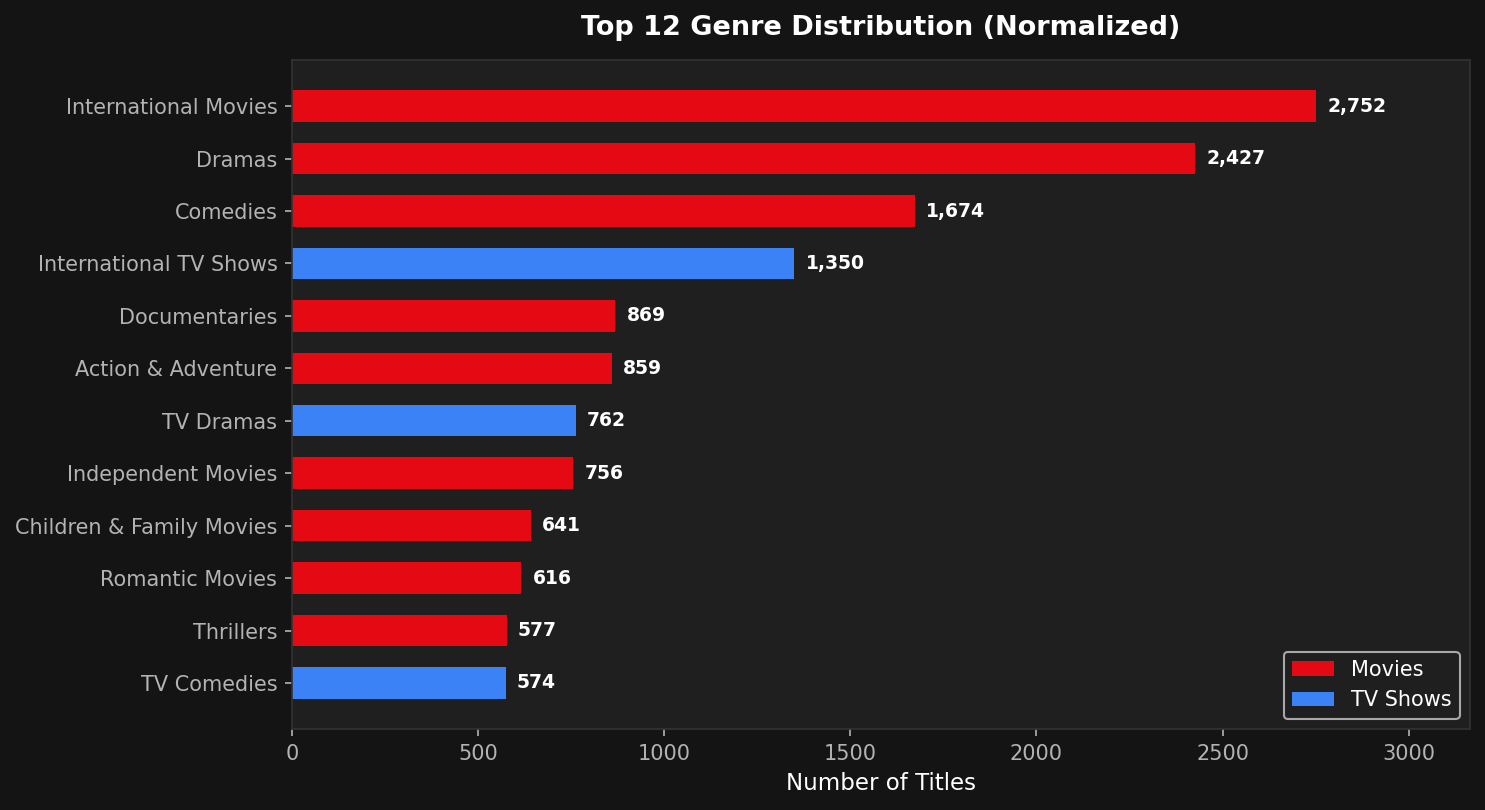

In [4]:
sql_genre = """
SELECT 
    g.genre,
    COUNT(*) AS total_count,
    SUM(CASE WHEN n.type = 'Movie' THEN 1 ELSE 0 END) AS movie_count,
    SUM(CASE WHEN n.type = 'TV Show' THEN 1 ELSE 0 END) AS tv_count
FROM genre_map g
JOIN netflix_titles n ON g.show_id = n.show_id
GROUP BY g.genre
ORDER BY total_count DESC
LIMIT 12;
"""
df_genre = pd.read_sql_query(sql_genre, conn)
display(df_genre)

# Visualization
df_sorted = df_genre.sort_values(by='total_count', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)
ax.barh(df_sorted['genre'], df_sorted['movie_count'], color=NETFLIX_RED, label='Movies', height=0.6)
ax.barh(df_sorted['genre'], df_sorted['tv_count'], left=df_sorted['movie_count'], color=ACCENT_BLUE, label='TV Shows', height=0.6)
ax.set_title('Top 12 Genre Distribution (Normalized)', fontweight='bold', pad=12)
ax.set_xlabel('Number of Titles')
ax.legend(loc='lower right')
for idx, total in enumerate(df_sorted['total_count']):
    ax.text(total + 30, idx, f'{total:,}', va='center', color='#FFF', fontsize=9, fontweight='bold')
ax.set_xlim(0, max(df_sorted['total_count']) * 1.15)
plt.tight_layout()
plt.show()


## 4. Rating Distribution & Audience Demographics
**Business Question:** How does the catalog skew in terms of maturity levels and family-friendliness?


,rating,movie_count,tv_count,total_count,pct_of_catalog
0,TV-MA,2062,1143,3205,36.4
1,TV-14,1427,730,2157,24.5
2,TV-PG,540,321,861,9.8
3,R,797,2,799,9.1
4,PG-13,490,0,490,5.6
5,TV-Y7,139,194,333,3.8
6,TV-Y,131,175,306,3.5
7,PG,287,0,287,3.3
8,TV-G,126,94,220,2.5
9,NR,75,4,79,0.9


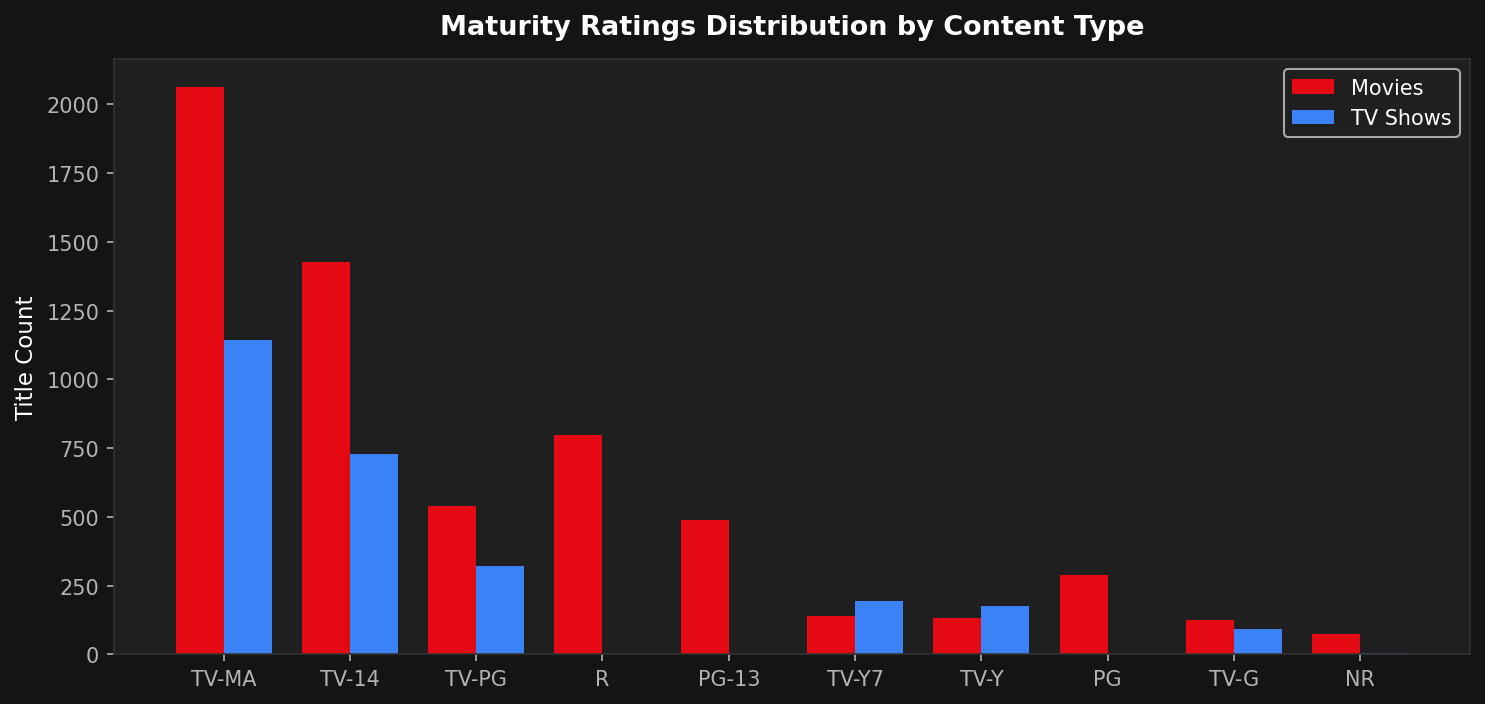

In [5]:
sql_ratings = """
SELECT 
    rating,
    SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) AS movie_count,
    SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) AS tv_count,
    COUNT(*) AS total_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM netflix_titles), 1) AS pct_of_catalog
FROM netflix_titles
WHERE rating <> 'Unknown'
GROUP BY rating
ORDER BY total_count DESC
LIMIT 10;
"""
df_ratings = pd.read_sql_query(sql_ratings, conn)
display(df_ratings)

# Visualization
fig, ax = plt.subplots(figsize=(10, 4.8), dpi=150)
w = 0.38
x = range(len(df_ratings))
ax.bar([i - w/2 for i in x], df_ratings['movie_count'], width=w, color=NETFLIX_RED, label='Movies')
ax.bar([i + w/2 for i in x], df_ratings['tv_count'], width=w, color=ACCENT_BLUE, label='TV Shows')
ax.set_xticks(x)
ax.set_xticklabels(df_ratings['rating'])
ax.set_title('Maturity Ratings Distribution by Content Type', fontweight='bold', pad=12)
ax.set_ylabel('Title Count')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 5. The Strategic Pivot: Production Vintage vs. Platform Ingestion
**Business Question:** How does original release year compare with the year added to Netflix, illustrating the shift toward originals?


,year,titles_released,titles_added
7,2012,236,3
8,2013,287,11
9,2014,352,24
10,2015,558,82
11,2016,901,429
12,2017,1032,1188
13,2018,1146,1649
14,2019,1030,2016
15,2020,953,1879
16,2021,592,1498


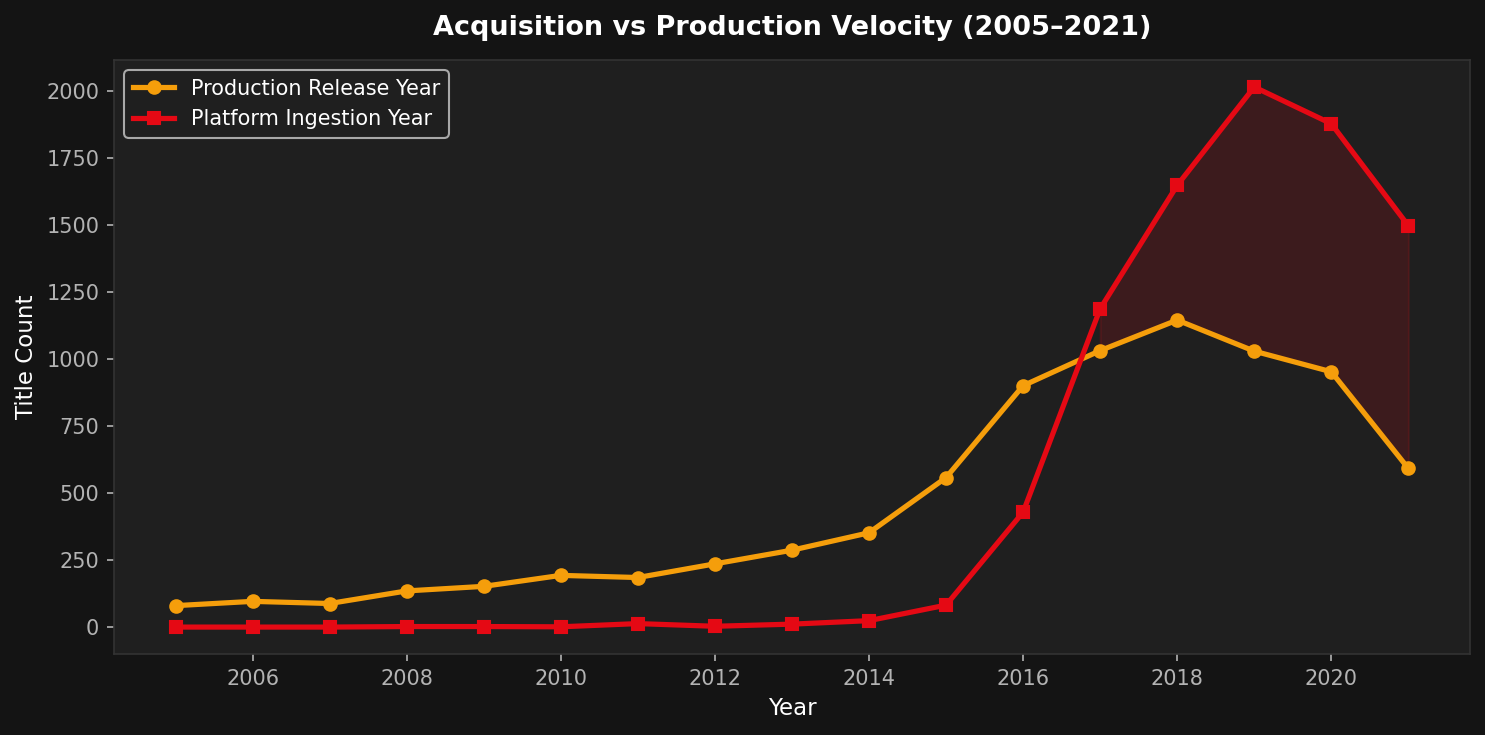

In [6]:
sql_trends = """
WITH release_stats AS (
    SELECT release_year AS year, COUNT(*) AS titles_released
    FROM netflix_titles
    WHERE release_year BETWEEN 2005 AND 2021
    GROUP BY release_year
),
added_stats AS (
    SELECT CAST(strftime('%Y', date_added) AS INTEGER) AS year, COUNT(*) AS titles_added
    FROM netflix_titles
    WHERE date_added IS NOT NULL AND CAST(strftime('%Y', date_added) AS INTEGER) BETWEEN 2005 AND 2021
    GROUP BY strftime('%Y', date_added)
)
SELECT 
    COALESCE(r.year, a.year) AS year,
    COALESCE(r.titles_released, 0) AS titles_released,
    COALESCE(a.titles_added, 0) AS titles_added
FROM release_stats r
FULL OUTER JOIN added_stats a ON r.year = a.year
ORDER BY year;
"""
df_trends = pd.read_sql_query(sql_trends, conn)
display(df_trends.tail(10))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.plot(df_trends['year'], df_trends['titles_released'], marker='o', color=ACCENT_GOLD, linewidth=2.5, label='Production Release Year')
ax.plot(df_trends['year'], df_trends['titles_added'], marker='s', color=NETFLIX_RED, linewidth=2.5, label='Platform Ingestion Year')
ax.fill_between(df_trends['year'], df_trends['titles_released'], df_trends['titles_added'],
                where=(df_trends['titles_added'] > df_trends['titles_released']), color=NETFLIX_RED, alpha=0.15)
ax.set_title('Acquisition vs Production Velocity (2005–2021)', fontweight='bold', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Title Count')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Geographic Footprint & Catalog Concentration
**Business Question:** Which countries produce the most content, and how concentrated is the catalog among the top producers?


In [7]:
sql_country = """
WITH country_counts AS (
    SELECT c.country, COUNT(DISTINCT c.show_id) AS title_count
    FROM country_map c
    WHERE c.country <> 'Unknown'
    GROUP BY c.country
),
total_titles AS (
    SELECT COUNT(*) AS total_catalog FROM netflix_titles
)
SELECT 
    cc.country,
    cc.title_count,
    ROUND(100.0 * cc.title_count / tt.total_catalog, 2) AS pct_of_catalog,
    ROUND(SUM(100.0 * cc.title_count / tt.total_catalog) OVER (ORDER BY cc.title_count DESC), 1) AS cumulative_pct
FROM country_counts cc
CROSS JOIN total_titles tt
ORDER BY cc.title_count DESC
LIMIT 10;
"""
df_country = pd.read_sql_query(sql_country, conn)
display(df_country)

# Regional Genre Specialization
sql_spec = """
SELECT c.country, g.genre, COUNT(*) AS count
FROM country_map c
JOIN genre_map g ON c.show_id = g.show_id
WHERE c.country IN ('United States', 'India', 'United Kingdom', 'Japan', 'South Korea')
GROUP BY c.country, g.genre
ORDER BY c.country, count DESC;
"""
df_spec = pd.read_sql_query(sql_spec, conn)
print('Top Specializations Sample:')
for cntry in ['United States', 'India', 'Japan', 'South Korea']:
    top_3 = df_spec[df_spec['country'] == cntry].head(3)[['genre', 'count']].to_dict('records')
    print(f'  {cntry}: {top_3}')


,country,title_count,pct_of_catalog,cumulative_pct
0,United States,3684,41.88,41.9
1,India,1046,11.89,53.8
2,United Kingdom,805,9.15,62.9
3,Canada,445,5.06,68.0
4,France,393,4.47,72.4
5,Japan,317,3.60,76.0
6,Spain,232,2.64,78.7
7,South Korea,231,2.63,81.3
8,Germany,226,2.57,83.9
9,Mexico,169,1.92,85.8


Top Specializations Sample:
  United States: [{'genre': 'Dramas', 'count': 835}, {'genre': 'Comedies', 'count': 680}, {'genre': 'Documentaries', 'count': 512}]
  India: [{'genre': 'International Movies', 'count': 864}, {'genre': 'Dramas', 'count': 662}, {'genre': 'Comedies', 'count': 323}]
  Japan: [{'genre': 'International TV Shows', 'count': 151}, {'genre': 'Anime Series', 'count': 142}, {'genre': 'International Movies', 'count': 72}]
  South Korea: [{'genre': 'International TV Shows', 'count': 152}, {'genre': 'Korean TV Shows', 'count': 132}, {'genre': 'Romantic TV Shows', 'count': 77}]


## 7. Release Cadence & Seasonality
**Business Question:** What seasonal patterns emerge when analyzing additions by calendar month?


,month_name,month_num,total_additions,movies_added,tv_shows_added
0,Jan,01,738,546,192
1,Feb,02,563,382,181
2,Mar,03,742,529,213
3,Apr,04,764,550,214
4,May,05,632,439,193
5,Jun,06,728,492,236
6,Jul,07,827,565,262
7,Aug,08,755,519,236
8,Sep,09,770,519,251
9,Oct,10,760,545,215


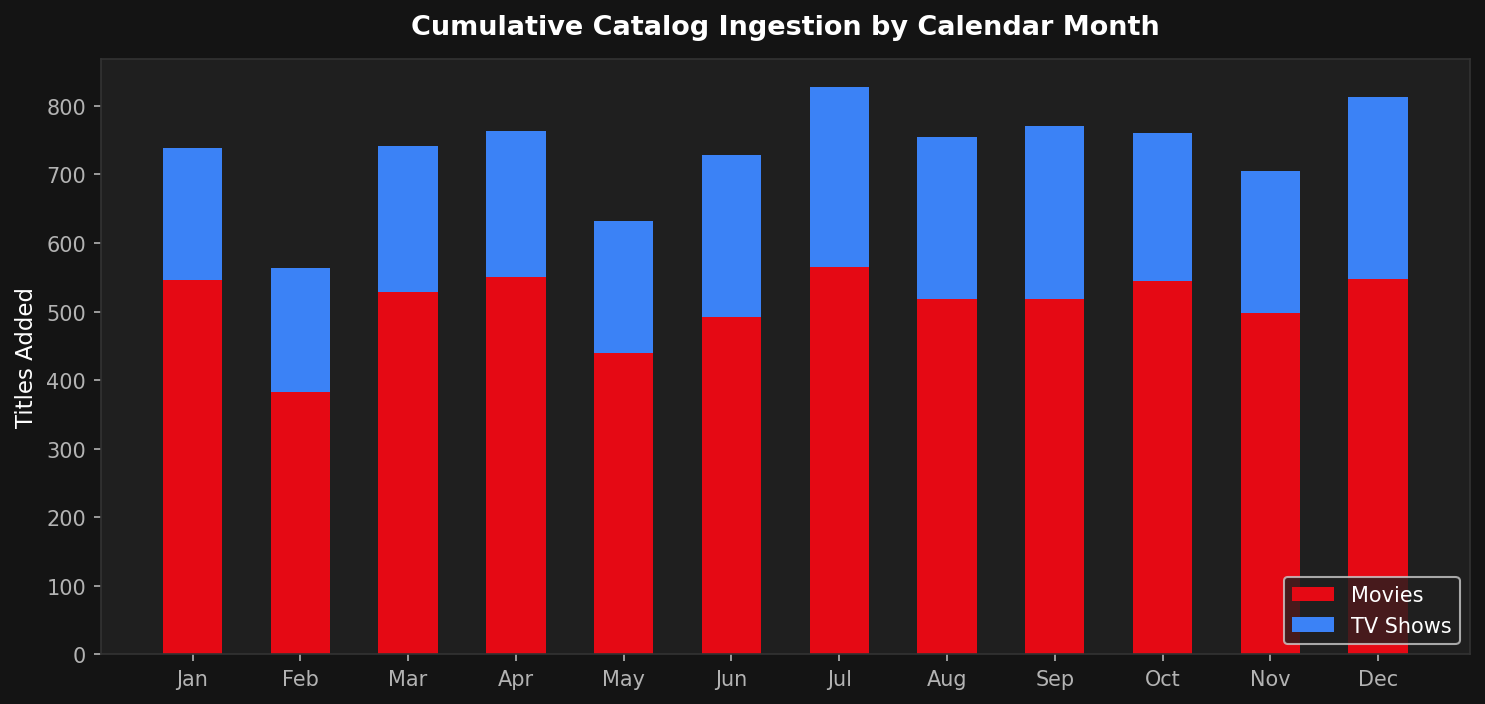

Analysis complete and database connection closed.


In [8]:
sql_cadence = """
SELECT 
    CASE strftime('%m', date_added)
        WHEN '01' THEN 'Jan' WHEN '02' THEN 'Feb' WHEN '03' THEN 'Mar'
        WHEN '04' THEN 'Apr' WHEN '05' THEN 'May' WHEN '06' THEN 'Jun'
        WHEN '07' THEN 'Jul' WHEN '08' THEN 'Aug' WHEN '09' THEN 'Sep'
        WHEN '10' THEN 'Oct' WHEN '11' THEN 'Nov' WHEN '12' THEN 'Dec'
    END AS month_name,
    strftime('%m', date_added) AS month_num,
    COUNT(*) AS total_additions,
    SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) AS movies_added,
    SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) AS tv_shows_added
FROM netflix_titles
WHERE date_added IS NOT NULL
GROUP BY month_num
ORDER BY month_num;
"""
df_cadence = pd.read_sql_query(sql_cadence, conn)
display(df_cadence)

fig, ax = plt.subplots(figsize=(10, 4.8), dpi=150)
x = range(len(df_cadence))
ax.bar(x, df_cadence['movies_added'], width=0.55, label='Movies', color=NETFLIX_RED)
ax.bar(x, df_cadence['tv_shows_added'], width=0.55, bottom=df_cadence['movies_added'], label='TV Shows', color=ACCENT_BLUE)
ax.set_xticks(x)
ax.set_xticklabels(df_cadence['month_name'])
ax.set_title('Cumulative Catalog Ingestion by Calendar Month', fontweight='bold', pad=12)
ax.set_ylabel('Titles Added')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

conn.close()
print('Analysis complete and database connection closed.')


## 8. Summary of Strategic Takeaways
- **Format Mix:** 69.7% Movies vs 30.3% TV Shows; TV additions increased from 25% to 33.7% between 2018 and 2021 to drive long-term subscriber retention.
- **Concentration Risk:** The Top 3 nations (US, India, UK) produce **62.9%** of all content on the platform, indicating potential supply chain licensing vulnerability.
- **Audience Positioning:** 61% of catalog titles carry adult classifications (TV-MA, TV-14), providing a strong moat in prestige drama but leaving an opening for competitors in family entertainment.
- **Seasonality:** Summer (July) and Year-End (December/January) consistently represent peak catalog drops, with concentrated spikes on the 1st of each calendar month.
